In [1]:
## load packages
import sys, os
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point, Polygon
import scipy.sparse as sp
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scrublet as scr
from contextlib import redirect_stdout
import spatialdata as sd
from spatialdata_io import xenium
from matplotlib.backends.backend_pdf import PdfPages


/homevol/kk/.local/lib/python3.9/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/homevol/kk/.local/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


# Add the TMA meta data info for each cell

In [3]:
#--------------------------------------------------------
# Annotate raw Xenium AnnData with polygon selections
#--------------------------------------------------------
def annotate_tma_raw(adata, coords_csv, tma, array_meta):
    import pandas as pd
    import geopandas as gpd
    from shapely.geometry import Point, Polygon
    
    adata.obs.index = adata.obs.index.astype(str)

    array_meta = array_meta.rename(columns=lambda c: c.strip().replace(" ", ""))

    #--------------------------------------------------------
    # Read polygon coordinates (per core) - obtained from XENIUM Explorer
    #--------------------------------------------------------
    coords = pd.read_csv(coords_csv, skiprows=2)

    polygons = {
        sel: Polygon(zip(df["X"], df["Y"]))
        for sel, df in coords.groupby("Selection")
    }

    poly_gdf = gpd.GeoDataFrame(
        {"arrayID": list(polygons.keys()), "geometry": list(polygons.values())},
        crs=None
    )

    #--------------------------------------------------------
    # Extract centroids from raw Xenium AnnData
    #--------------------------------------------------------
    spatial = adata.obsm["spatial"]  # Nx2 array
    centroids_df = pd.DataFrame({
        "cell_id": adata.obs["cell_id"].values,
        "x": spatial[:, 0],
        "y": spatial[:, 1]
    })

    cell_gdf = gpd.GeoDataFrame(
        centroids_df,
        geometry=[Point(xy) for xy in zip(centroids_df.x, centroids_df.y)],
        crs=None
    )

    #--------------------------------------------------------
    # assign each cell to a polygon
    #--------------------------------------------------------
    joined = gpd.sjoin(cell_gdf, poly_gdf, predicate="within", how="left")

    #--------------------------------------------------------
    # Add arrayID + TMA label to AnnData.obs
    #--------------------------------------------------------
    adata.obs["arrayID"] = joined["arrayID"].fillna("unassigned").values
    adata.obs["tma"] = tma

    #--------------------------------------------------------
    # Merge with array metadata (PatientID, Diagnosis, etc.)
    #--------------------------------------------------------
    if "arrayID" in array_meta.columns:
        adata.obs = (
            adata.obs.reset_index()
            .merge(array_meta, how="left", on="arrayID")
            .set_index("index")
        )

    return adata


In [4]:
#--------------------------------------------------------
# Working directory and metadata
#--------------------------------------------------------
base = "~/analysis/OVA_TMA/Old/TMA5_TMA6"

hgsoc_samples_clin = pd.read_csv(f"{base}/meta_data/OC_samples_clin.csv") 

hgsoc_samples_array_ids = (
    pd.read_csv(f"{base}/meta_data/TMA_patient_id_array_ids.csv")
      .query("PatientID in @hgsoc_samples_clin.OVDB_ID or PatientID == 'Unknown'")
      .assign(Diagnosis=lambda df: np.where(df.Diagnosis == "normal", "Normal", "Tumour"))
      .assign(Diagnosis=lambda df: np.where(df.PatientID == "Unknown", "Unknown", df.Diagnosis))
      .rename(columns={"array ID": "arrayID"}) 
)

In [7]:
#### annotating the original raw xenium data

In [4]:
tma6l_og = xenium("/homevol/kk/analysis/OVA_TMA/Old/TMA6_only/from_full_xenium_data/output-XETG00141__0052404__TMA6L__20250611__063424")
tma6r_og = xenium("/homevol/kk/analysis/OVA_TMA/Old/TMA6_only/from_full_xenium_data/output-XETG00141__0052407__TMA6R__20250611__063425")

INFO     reading                                                                                                   
         /homevol/kk/analysis/OVA_TMA/Old/TMA6_only/from_full_xenium_data/output-XETG00141__0052404__TMA6L__2025061
         1__063424/cell_feature_matrix.h5                                                                          


/tmp/ipykernel_173081/926386379.py:1: DeprecationWarning: The default value of `cells_as_circles` will change to `False` in the next release. Please pass `True` explicitly to maintain the current behavior.
  tma6l_og = xenium("/homevol/kk/analysis/OVA_TMA/Old/TMA6_only/from_full_xenium_data/output-XETG00141__0052404__TMA6L__20250611__063424")


INFO     reading                                                                                                   
         /homevol/kk/analysis/OVA_TMA/Old/TMA6_only/from_full_xenium_data/output-XETG00141__0052407__TMA6R__2025061
         1__063425/cell_feature_matrix.h5                                                                          


/tmp/ipykernel_173081/926386379.py:2: DeprecationWarning: The default value of `cells_as_circles` will change to `False` in the next release. Please pass `True` explicitly to maintain the current behavior.
  tma6r_og = xenium("/homevol/kk/analysis/OVA_TMA/Old/TMA6_only/from_full_xenium_data/output-XETG00141__0052407__TMA6R__20250611__063425")


In [11]:
tma6l_og = tma6l_og.tables["table"]

In [12]:
tma6l_og

AnnData object with n_obs × n_vars = 576334 × 480
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

In [13]:
tma6r_og = tma6r_og.tables["table"]

In [14]:
tma6r_og

AnnData object with n_obs × n_vars = 572257 × 480
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

In [15]:
## Annotate the TMA

tma6l_og = annotate_tma_raw(
    adata=tma6l_og,
    coords_csv=f"{base}/TMA_core_coordinates/coordinates_TMA6L.csv",
    tma="TMA6L",
    array_meta=hgsoc_samples_array_ids
)

tma6r_og = annotate_tma_raw(
    adata=tma6r_og,
    coords_csv=f"{base}/TMA_core_coordinates/coordinates_TMA6R.csv",
    tma="TMA6R",
    array_meta=hgsoc_samples_array_ids
)

In [26]:
tma6l_og.obs[['arrayID','tma','PatientID','Diagnosis']].isna().sum()

arrayID        0
tma            0
PatientID    205
Diagnosis    205
dtype: int64

In [30]:
tma6l_og.obs[['arrayID','tma','PatientID','Diagnosis']].apply(lambda col: col.str.lower().eq('unassigned').sum())


arrayID      205
tma            0
PatientID      0
Diagnosis      0
dtype: int64

In [16]:
tma6l_og

AnnData object with n_obs × n_vars = 576334 × 480
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'arrayID', 'tma', 'PatientID', 'Diagnosis'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

In [24]:
# Extract the columns required
df = tma6l_og.obs[['cell_id', 'arrayID', 'tma', 'PatientID', 'Diagnosis']].copy()

# Add prefix "L_" to cell_id
df['cell_id'] = 'L_' + df['cell_id'].astype(str)

# Save to CSV
df.to_csv('/homevol/kk/analysis/OVA_TMA/Old/TMA5_TMA6/tma6l_og_metadata.csv', index=False)


In [27]:
tma6r_og.obs[['arrayID','tma','PatientID','Diagnosis']].isna().sum()

arrayID        0
tma            0
PatientID    167
Diagnosis    167
dtype: int64

In [31]:
tma6r_og.obs[['arrayID','tma','PatientID','Diagnosis']].apply(lambda col: col.str.lower().eq('unassigned').sum())


arrayID      167
tma            0
PatientID      0
Diagnosis      0
dtype: int64

In [17]:
tma6r_og

AnnData object with n_obs × n_vars = 572257 × 480
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'arrayID', 'tma', 'PatientID', 'Diagnosis'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

In [ ]:
# Extract cell-id specific information to join with the MisTIC-adjusted clean anndata

df = tma6l_og.obs[['cell_id', 'arrayID', 'tma', 'PatientID', 'Diagnosis']].copy()

# Add prefix "L_" to cell_id
df['cell_id'] = 'R_' + df['cell_id'].astype(str)

# Save to CSV
df.to_csv('/homevol/kk/analysis/OVA_TMA/Old/TMA5_TMA6/tma6l_og_metadata.csv', index=False)


In [25]:
# Extract cell-id specific information to join with the MisTIC-adjusted clean anndata

df = tma6r_og.obs[['cell_id', 'arrayID', 'tma', 'PatientID', 'Diagnosis']].copy()

# Add prefix "L_" to cell_id
df['cell_id'] = 'R_' + df['cell_id'].astype(str)

# Save to CSV
df.to_csv('/homevol/kk/analysis/OVA_TMA/Old/TMA5_TMA6/tma6r_og_metadata.csv', index=False)


In [23]:
tma6l_og.write_h5ad("/homevol/kk/analysis/OVA_TMA/Old/TMA5_TMA6/TMA6L_xenium_meta_annot.h5ad")
tma6r_og.write_h5ad("/homevol/kk/analysis/OVA_TMA/Old/TMA5_TMA6/TMA6R_xenium_meta_annot.h5ad")

# Merge and adjust coordinates of the two slices of TMA6

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import spatialdata as sd
import geopandas as gpd
from shapely.affinity import translate

###############################################
tx_L = tma6l_og.points["transcripts"].compute()
tx_R = tma6r_og.points["transcripts"].compute()

polys_L = tma6l_og.shapes["cell_boundaries"]
polys_R = tma6r_og.shapes["cell_boundaries"]

tx_L = tx_L[tx_L["assignment"].notna()].copy()
tx_R = tx_R[tx_R["assignment"].notna()].copy()

###############################################
def prefix_adata(adata, prefix, source_label):
    adata.obs_names = prefix + adata.obs_names.astype(str)
    adata.obs["cell"] = prefix + adata.obs["cell"].astype(str)
    adata.obs["original_cell_id"] = prefix + adata.obs["original_cell_id"].astype(str)
    adata.obs["source"] = source_label
    return adata

adata_L = prefix_adata(adata_L, "L_", "TMA6L")
adata_R = prefix_adata(adata_R, "R_", "TMA6R")

polys_L["cell"] = "L_" + polys_L["cell"].astype(str)
polys_R["cell"] = "R_" + polys_R["cell"].astype(str)

id_col = "transcript_id" if "transcript_id" in tx_L.columns else "id"
tx_L[id_col] = "L_" + tx_L[id_col].astype(str)
tx_R[id_col] = "R_" + tx_R[id_col].astype(str)

tx_L["assignment"] = "L_" + tx_L["assignment"].astype(str)
tx_R["assignment"] = "R_" + tx_R["assignment"].astype(str)

###############################################
adata = sc.concat([adata_L, adata_R], join="outer", fill_value=0)

###############################################
sp = adata.obsm["spatial"]
obs = adata.obs

maskL = obs["source"].isin(["TMA6L", "L"])
maskR = obs["source"].isin(["TMA6R", "R"])

# top of L, bottom of R
yL_max = np.percentile(sp[maskL, 1], 99)
yR_min = np.percentile(sp[maskR, 1], 1)

epsilon = 10  # tiny separation, prevents touching/overlapping but keeps them close
dy = yL_max - yR_min + epsilon
dx = 0

###############################################
adata.obsm["spatial_original"] = adata.obsm["spatial"].copy()

adata.obsm["spatial"][maskR, 1] += dy

if "centroid_y" in adata.obs.columns:
    adata.obs.loc[maskR, "centroid_y"] += dy

###############################################
mask_tx_R = tx_R["assignment"].str.startswith("R_")
tx_R.loc[mask_tx_R, "y"] += dy

###############################################
mask_poly_R = polys_R["cell"].str.startswith("R_")
polys_R.loc[mask_poly_R, "geometry"] = (
    polys_R.loc[mask_poly_R, "geometry"].apply(lambda g: translate(g, yoff=dy))
)

###############################################
tx_merged = pd.concat([tx_L, tx_R], ignore_index=True)

polys_merged = gpd.GeoDataFrame(
    pd.concat([polys_L, polys_R], ignore_index=True),
    geometry="geometry",
    crs=polys_L.crs
)

###############################################
adata.uns.setdefault("spatial_shifts", {})
adata.uns["spatial_shifts"]["TMA6R_vertical_rim_shift"] = {
    "yL_max_99": float(yL_max),
    "yR_min_01": float(yR_min),
    "epsilon": float(epsilon),
    "applied_dy": float(dy),
    "method": "minimal_gap_percentile_rim_alignment"
}


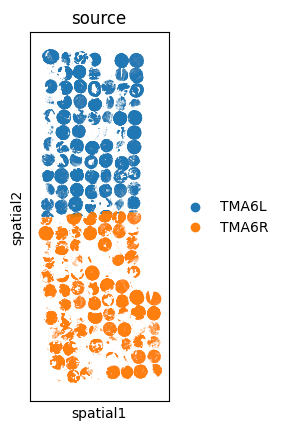

In [16]:
sc.pl.spatial(
    adata,
    color='source',
    spot_size=20,
    cmap='viridis'
)